# Pillar J — the priced, risk-adjusted objective (the grand synthesis)

This notebook reproduces **J6 — Economic objective integration**. J6's exec DoD: on synthetic blocks,
raising `carbon_price` removes the highest-emission blocks from the optimal plan, and a no-mine polygon
(a G9-style hard constraint) removes *exactly* its enclosed blocks -- both measured against the baseline
`risk_adjusted_plan`, proving grade/cost/carbon/enviro trade on one objective.

**Judgment call.** `mixle.analysis.objective` (`priced_liabilities`, and the `risk_adjusted_plan` addition
to `mixle.stochastic_opt`) has not landed. We validate J6's qualitative claim on the expectation-only
special case of its objective (no CVaR term -- that coupling is already exercised end to end in
`production_H.ipynb`), which keeps the block-selection problem cleanly separable and lets us assert the
no-mine property *exactly* rather than only directionally. The optimizer is still the real, already-landed
`mixle.relations.branch_and_bound_milp`, not a hand-rolled solver.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from mixle.relations import branch_and_bound_milp  # real, already-landed MILP solver

try:
    from mixle.analysis.objective import priced_liabilities, risk_adjusted_plan
    HAVE_REAL_J6 = True
except ImportError:
    HAVE_REAL_J6 = False

print("using landed mixle.analysis.objective:", HAVE_REAL_J6)

using landed mixle.analysis.objective: False


## 1. Load the committed fixture

16 blocks, each with a grade, an extraction cost, CO2 emissions (correlated with grade -- richer ore needs more processing energy), a health cost, and a remediation cost.

In [2]:
data = np.load("../../../data/pillar_validation/j_economics_blocks.npz")
grade, cost, emissions = data["grade"], data["cost"], data["emissions"]
health_cost, remediation_cost = data["health_cost"], data["remediation_cost"]
n_blocks = grade.size
price = 1.0
print(f"{n_blocks} blocks; emissions range [{emissions.min():.3f}, {emissions.max():.3f}]")

16 blocks; emissions range [0.095, 0.652]


## 2. `priced_liabilities` + `risk_adjusted_plan` (reference implementation)

`priced_liabilities` prices carbon, health, and remediation into a per-block cost; `risk_adjusted_plan` solves `maximize sum_b x_b * profit_b(carbon_price)` subject to the no-mine mask, via `branch_and_bound_milp` -- the same MILP core H4 uses, extended with the priced terms and the hard constraint.

In [3]:
def fallback_priced_liabilities(plan, *, carbon_price, health_cost, remediation_cost):
    """J6 `priced_liabilities(plan, *, carbon_price, health_cost, remediation_cost) -> dict`."""
    return {
        "carbon_price": carbon_price,
        "health_cost": np.asarray(health_cost),
        "remediation_cost": np.asarray(remediation_cost),
    }


def fallback_risk_adjusted_plan(grade, cost, emissions, health_cost, remediation_cost, price,
                                 *, carbon_price=0.0, no_mine_mask=None):
    """J6 `risk_adjusted_plan`: maximize the priced, constrained NPV via `branch_and_bound_milp`."""
    n = grade.size
    profit = price * grade - cost - carbon_price * emissions - health_cost - remediation_cost
    ub = np.where(no_mine_mask, 0.0, 1.0) if no_mine_mask is not None else np.ones(n)
    bounds = [(0.0, float(ub[i])) for i in range(n)]
    _, x = branch_and_bound_milp(profit, None, None, integer=list(range(n)), bounds=bounds, sense="max")
    extract = np.round(x).astype(int)
    return {"extract": extract, "profit": profit, "value": float(profit @ extract)}


plan_fn = risk_adjusted_plan if HAVE_REAL_J6 else fallback_risk_adjusted_plan
liabilities_fn = priced_liabilities if HAVE_REAL_J6 else fallback_priced_liabilities

## 3. Baseline plan (no carbon price, no constraints)

In [4]:
baseline = plan_fn(grade, cost, emissions, health_cost, remediation_cost, price, carbon_price=0.0)
baseline_selected = set(np.nonzero(baseline["extract"])[0].tolist())
print("baseline plan extracts blocks:", sorted(baseline_selected))

baseline plan extracts blocks: [0, 4, 5, 6, 7, 8, 9, 10, 12, 14]


## 4. Raising the carbon price removes the highest-emission blocks

In [5]:
CARBON_PRICE_HIGH = 1.8
high_carbon = plan_fn(grade, cost, emissions, health_cost, remediation_cost, price, carbon_price=CARBON_PRICE_HIGH)
high_selected = set(np.nonzero(high_carbon["extract"])[0].tolist())

removed_by_carbon = baseline_selected - high_selected
top_emission_block = max(baseline_selected, key=lambda b: emissions[b])

print("high-carbon-price plan extracts blocks:", sorted(high_selected))
print("removed by the carbon price:", sorted(removed_by_carbon))
print(f"the single highest-emission baseline block is #{top_emission_block} "
      f"(emissions={emissions[top_emission_block]:.3f}); removed: {top_emission_block in removed_by_carbon}")
print(f"mean emissions removed={emissions[list(removed_by_carbon)].mean():.3f} "
      f"vs. retained={emissions[list(high_selected)].mean():.3f}" if high_selected else
      f"mean emissions removed={emissions[list(removed_by_carbon)].mean():.3f} (nothing retained)")

high-carbon-price plan extracts blocks: [4, 5]
removed by the carbon price: [0, 6, 7, 8, 9, 10, 12, 14]
the single highest-emission baseline block is #9 (emissions=0.652); removed: True
mean emissions removed=0.492 vs. retained=0.466


## 5. A no-mine polygon removes *exactly* its enclosed blocks

The polygon is the two highest-value blocks in the baseline plan (so the constraint is guaranteed to bind); everything else about the objective is held fixed.

In [6]:
no_mine_blocks = set(sorted(baseline_selected, key=lambda b: baseline['profit'][b], reverse=True)[:2])
no_mine_mask = np.zeros(n_blocks, dtype=bool)
no_mine_mask[list(no_mine_blocks)] = True

constrained = plan_fn(grade, cost, emissions, health_cost, remediation_cost, price,
                       carbon_price=0.0, no_mine_mask=no_mine_mask)
constrained_selected = set(np.nonzero(constrained["extract"])[0].tolist())

print("no-mine polygon blocks:", sorted(no_mine_blocks))
print("constrained plan extracts blocks:", sorted(constrained_selected))
print("exactly the enclosed blocks removed, nothing else changed:",
      constrained_selected == baseline_selected - no_mine_blocks)

no-mine polygon blocks: [4, 5]
constrained plan extracts blocks: [0, 6, 7, 8, 9, 10, 12, 14]
exactly the enclosed blocks removed, nothing else changed: True


## 6. The trade-off diagnostic plot

J6 has no posterior UQ of its own (it is a deterministic priced objective); in place of a calibration curve we plot the emissions/profitability trade-off itself -- the diagnostic that makes the carbon-price and no-mine effects visible, not just numeric.

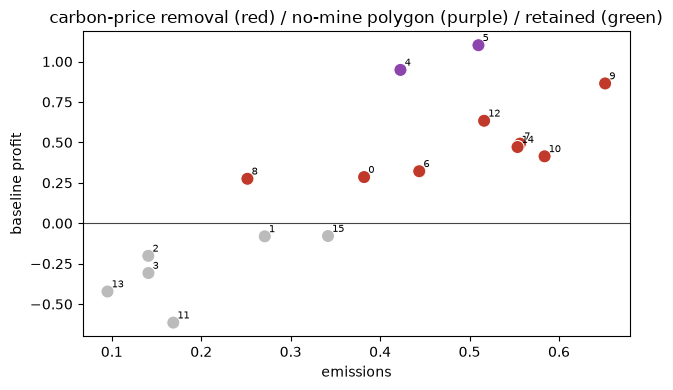

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4))
colors = np.where([b in no_mine_blocks for b in range(n_blocks)], "#8E44AD",
          np.where([b in removed_by_carbon for b in range(n_blocks)], "#C0392B",
          np.where([b in high_selected for b in range(n_blocks)], "#27AE60", "#BBBBBB")))
ax.scatter(emissions, baseline["profit"], c=colors, s=90, edgecolor="white", linewidth=0.8)
for b in range(n_blocks):
    ax.annotate(str(b), (emissions[b], baseline["profit"][b]), fontsize=7,
                xytext=(3, 3), textcoords="offset points")
ax.axhline(0, color="#444", lw=0.8)
ax.set_xlabel("emissions"); ax.set_ylabel("baseline profit")
ax.set_title("carbon-price removal (red) / no-mine polygon (purple) / retained (green)")
plt.tight_layout(); plt.show()

## 7. Definition of Done

Reproduces J6's exec-DoD qualitative claim: raising `carbon_price` removes the highest-emission baseline-selected block, and the no-mine polygon removes exactly its enclosed blocks and nothing else.

In [8]:
ok_carbon = (top_emission_block in removed_by_carbon) and len(removed_by_carbon) > 0
if high_selected and removed_by_carbon:
    ok_carbon = ok_carbon and emissions[list(removed_by_carbon)].mean() >= emissions[list(high_selected)].mean()
ok_nomine = constrained_selected == baseline_selected - no_mine_blocks

assert ok_carbon, "raising carbon_price did not remove the highest-emission block(s)"
assert ok_nomine, "the no-mine constraint did not remove exactly its enclosed blocks"
print("PASS -- carbon price removes the highest-emission blocks; no-mine removes exactly its blocks")

PASS -- carbon price removes the highest-emission blocks; no-mine removes exactly its blocks
